<a href="https://colab.research.google.com/github/eparks8/ECGR-5105-Intro-to-ML/blob/main/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4: SVM and SVR

## Imports

### Libraries

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.svm import SVC, SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Google Drive Imports
from google.colab import drive

### Data

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df_cancer = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HW4/Cancer.csv")
df_cancer = df_cancer.drop(columns='id')
df_cancer.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df_housing = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HW4/Housing.csv")
df_housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Problem 1: SVM Classifier

Fitting 5 folds for each of 144 candidates, totalling 720 fits
CPU times: user 7.93 s, sys: 16.3 ms, total: 7.95 s
Wall time: 8.52 s
Best parameters found: {'C': 10000, 'gamma': 1e-05, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        69
           M       1.00      0.96      0.98        45

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



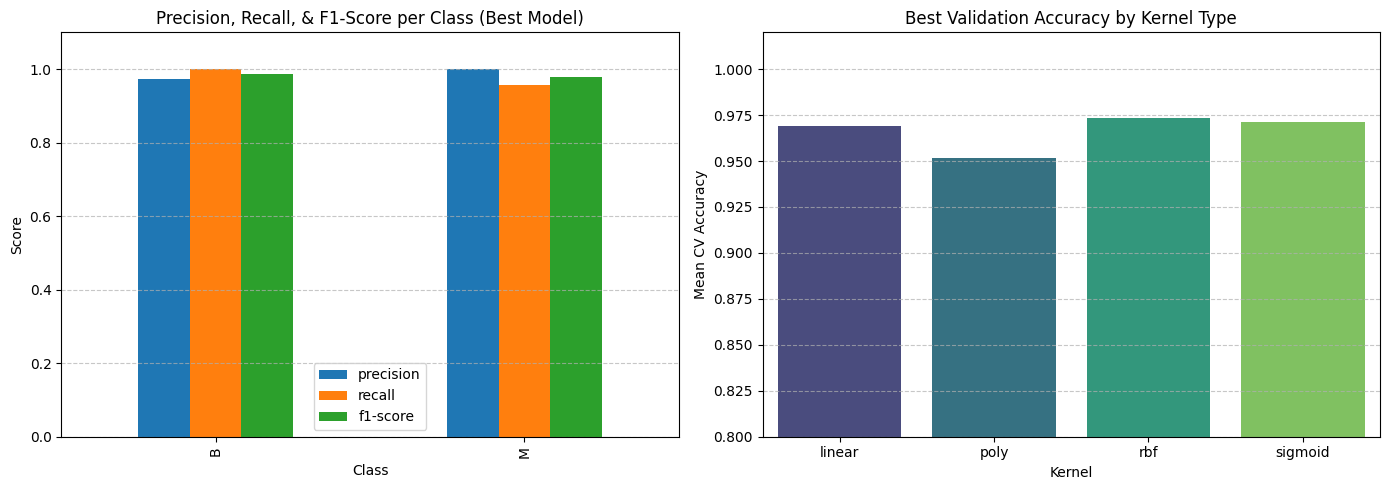

In [5]:
X = df_cancer.drop(columns='diagnosis')
Y = df_cancer['diagnosis']
svm_scaler = StandardScaler()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=5105)
X_train = svm_scaler.fit_transform(X_train)
X_test = svm_scaler.transform(X_test)

param_grid = {'C': [0.1, 1, 10, 100, 1000, 10000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001, 0.00001],
              'kernel': ['linear','rbf','poly','sigmoid']}

svc = SVC()
grid = GridSearchCV(svc, param_grid, refit=True, verbose=1)

# Corrected the variable names here from Xtrain/ytrain to X_train/Y_train
%time grid.fit(X_train, Y_train)
print("Best parameters found:", grid.best_params_)

# Use the best estimator found during the grid search
best_model = grid.best_estimator_
Y_pred = best_model.predict(X_test)

# Print the classification report
report_dict = classification_report(Y_test, Y_pred, output_dict=True)
print(classification_report(Y_test, Y_pred))

# Visualize metrics
metrics_df = pd.DataFrame(report_dict).transpose().iloc[:2, :3]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

metrics_df.plot(kind='bar', ax=ax[0])
ax[0].set_title("Precision, Recall, & F1-Score per Class (Best Model)")
ax[0].set_ylim(0, 1.1)
ax[0].set_ylabel("Score")
ax[0].set_xlabel("Class")
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Extract grid search results to compare kernels
results = pd.DataFrame(grid.cv_results_)
kernel_comparison = results.groupby('param_kernel')['mean_test_score'].max().reset_index()

sns.barplot(x='param_kernel', y='mean_test_score', data=kernel_comparison, ax=ax[1], palette='viridis', hue='param_kernel', legend=False)
ax[1].set_title("Best Validation Accuracy by Kernel Type")
ax[1].set_ylim(0.8, 1.02)
ax[1].set_ylabel("Mean CV Accuracy")
ax[1].set_xlabel("Kernel")
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Problem 2: SVM Regressor (SVR)


/tmp/ipykernel_17750/4233168415.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_housing[binary_cols] = df_housing[binary_cols].replace(binary_map)


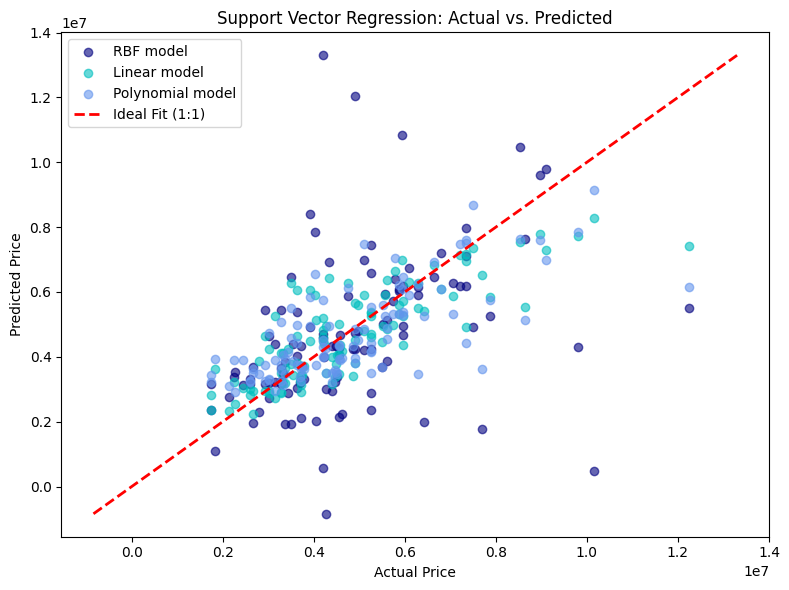

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

df_housing = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HW4/Housing.csv")

binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
binary_map = {'yes': 1, 'no': 0}

df_housing[binary_cols] = df_housing[binary_cols].replace(binary_map)
df_housing_clean = df_housing.dropna(subset=binary_cols + ['area', 'bedrooms', 'bathrooms', 'stories', 'price'])

X = df_housing_clean.drop(['price','furnishingstatus'], axis=1)
Y = df_housing_clean['price']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=5105
)

feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

# Fit SVR using TransformedTargetRegressor to auto-scale 'Y'
svr_rbf = TransformedTargetRegressor(
    regressor=SVR(kernel='rbf', C=1e3, gamma=0.1), transformer=StandardScaler()
)
svr_lin = TransformedTargetRegressor(
    regressor=SVR(kernel='linear', C=1e3), transformer=StandardScaler()
)
svr_poly = TransformedTargetRegressor(
    regressor=SVR(kernel='poly', C=1e3, degree=2), transformer=StandardScaler()
)

y_rbf = svr_rbf.fit(X_train_scaled, Y_train).predict(X_test_scaled)
y_lin = svr_lin.fit(X_train_scaled, Y_train).predict(X_test_scaled)
y_poly = svr_poly.fit(X_train_scaled, Y_train).predict(X_test_scaled)

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_rbf, color='navy', alpha=0.6, label='RBF model')
plt.scatter(Y_test, y_lin, color='c', alpha=0.6, label='Linear model')
plt.scatter(
    Y_test, y_poly, color='cornflowerblue', alpha=0.6, label='Polynomial model'
)

min_val = min(Y_test.min(), min(y_rbf.min(), y_lin.min(), y_poly.min()))
max_val = max(Y_test.max(), max(y_rbf.max(), y_lin.max(), y_poly.max()))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    lw=2,
    label='Ideal Fit (1:1)',
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Support Vector Regression: Actual vs. Predicted')
plt.legend()
plt.tight_layout()
plt.show()

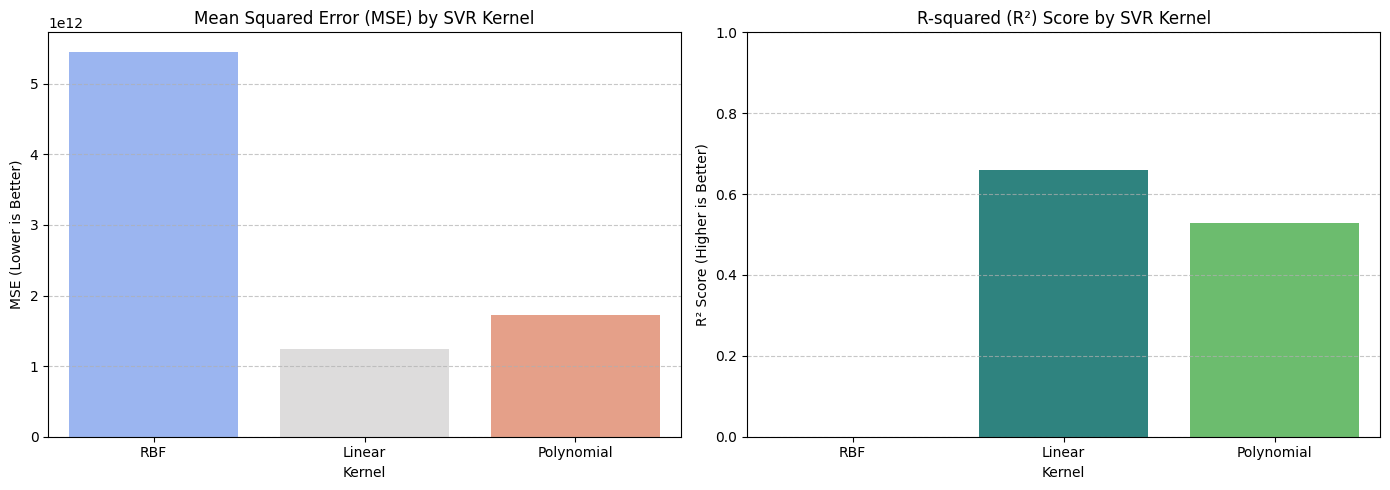

,Kernel,MSE,R2
0,RBF,5.455799e+12,-0.492496
1,Linear,1.245887e+12,0.659173
2,Polynomial,1.719833e+12,0.529520


In [13]:
from sklearn.metrics import mean_squared_error, r2_score

metrics = {
    'Kernel': ['RBF', 'Linear', 'Polynomial'],
    'MSE': [
        mean_squared_error(Y_test, y_rbf),
        mean_squared_error(Y_test, y_lin),
        mean_squared_error(Y_test, y_poly)
    ],
    'R2': [
        r2_score(Y_test, y_rbf),
        r2_score(Y_test, y_lin),
        r2_score(Y_test, y_poly)
    ]
}

df_metrics = pd.DataFrame(metrics)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE
sns.barplot(x='Kernel', y='MSE', data=df_metrics, ax=axes[0], palette='coolwarm', hue='Kernel', legend=False)
axes[0].set_title('Mean Squared Error (MSE) by SVR Kernel')
axes[0].set_ylabel('MSE (Lower is Better)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# R-squared Score
sns.barplot(x='Kernel', y='R2', data=df_metrics, ax=axes[1], palette='viridis', hue='Kernel', legend=False)
axes[1].set_title('R-squared (R²) Score by SVR Kernel')
axes[1].set_ylabel('R² Score (Higher is Better)')
axes[1].set_ylim(bottom=0.0, top=1.0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

display(df_metrics)